In [1]:
import sys
import os
from pathlib import Path

# Tambahkan root project ke path agar bisa import modul footballanalytix
current_dir = Path(os.getcwd())
project_root = current_dir.parent
sys.path.append(str(project_root))

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Import modul internal
from footballanalytix.config import FIELD_MODEL_PATH, DEFAULT_VIDEO_PATH
from footballanalytix.field import SoccerPitchConfiguration, detect_field_keypoints

print(f"Project Root: {project_root}")
print(f"Model Path: {FIELD_MODEL_PATH}")

Project Root: e:\Project\FootballAnalytix
Model Path: E:\Project\FootballAnalytix\Models\Fields.pt


Model loaded successfully.


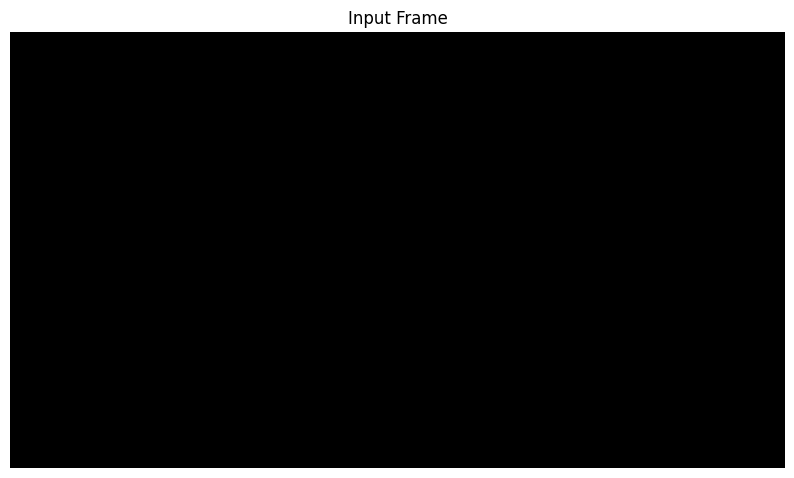

In [2]:
# Load Model
try:
    field_model = YOLO(FIELD_MODEL_PATH)
    print("Model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Pastikan file 'Models/Fields.pt' ada.")

# Load Sample Frame dari Video
video_path = DEFAULT_VIDEO_PATH
# Jika video default tidak ada, bisa ganti path di sini
# video_path = "path/to/your/video.mp4"

cap = cv2.VideoCapture(str(video_path))
if not cap.isOpened():
    print(f"Warning: Video not found at {video_path}. Using dummy black image for code structure demonstration.")
    frame = np.zeros((720, 1280, 3), dtype=np.uint8)
else:
    # Ambil frame ke-100 agar lapangan terlihat jelas
    cap.set(cv2.CAP_PROP_POS_FRAMES, 100)
    ret, frame = cap.read()
    if not ret:
        print("Failed to read frame.")
        frame = np.zeros((720, 1280, 3), dtype=np.uint8)
    cap.release()

# Tampilkan Frame
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("Input Frame")
plt.axis('off')
plt.show()

In [4]:
# Konfigurasi Lapangan
config = SoccerPitchConfiguration()

# Deteksi Keypoints
# Confidence threshold kita set agak tinggi biar dapet point yang bagus
frame_points, pitch_points, avg_conf = detect_field_keypoints(frame, field_model, config, confidence=0.5)

print(f"Detected {len(frame_points)} keypoints.")
print(f"Average Confidence: {avg_conf:.4f}")

# Visualisasi Titik yang Terdeteksi
frame_vis = frame.copy()
for pt in frame_points:
    cv2.circle(frame_vis, (int(pt[0]), int(pt[1])), 5, (0, 255, 255), -1)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Keypoints (n={len(frame_points)})")
plt.axis('off')
plt.show()

# Tampilkan beberapa sampel data
print("\nSample Correspondences:")
print("{:<20} | {:<20}".format("Frame (x, y)", "Pitch (x', y')"))
print("-" * 45)
for i in range(min(5, len(frame_points))):
    fx, fy = frame_points[i]
    px, py = pitch_points[i]
    print(f"({fx:8.2f}, {fy:8.2f}) | ({px:8.2f}, {py:8.2f})")

IndexError: index 0 is out of bounds for dimension 0 with size 0

## 3. Teori: Direct Linear Transformation (DLT)

Homography matrix $H$ adalah matriks $3 \times 3$ yang memetakan titik $x$ ke $x'$:

$$
s \begin{pmatrix} x' \\ y' \\ 1 \end{pmatrix} = 
\begin{pmatrix} h_1 & h_2 & h_3 \\ h_4 & h_5 & h_6 \\ h_7 & h_8 & h_9 \end{pmatrix} 
\begin{pmatrix} x \\ y \\ 1 \end{pmatrix}
$$

Kita bisa menghilangkan scale factor $s$ dengan cross product, yang menghasilkan sistem persamaan linear homogen $Ah = 0$.
Untuk setiap pasangan titik $(x, y) \to (x', y')$, kita dapatkan 2 baris di matriks $A$:

$$
\begin{pmatrix}
-x & -y & -1 & 0 & 0 & 0 & xx' & yx' & x' \\
0 & 0 & 0 & -x & -y & -1 & xy' & yy' & y'
\end{pmatrix}
\begin{pmatrix} h_1 \\ \vdots \\ h_9 \end{pmatrix} = \mathbf{0}
$$

Jika kita punya $N$ titik, matriks $A$ akan berukuran $2N \times 9$.
Solusi untuk $h$ adalah **eigenvector** yang berkorespondensi dengan **eigenvalue terkecil** dari $A^T A$, atau secara ekuivalen, **right singular vector** terakhir dari **SVD** matriks $A$.

In [ ]:
def calculate_homography_dlt(src_points, dst_points):
    """
    Menghitung Homography Matrix menggunakan DLT dan SVD.
    
    Args:
        src_points: Nx2 numpy array (titik di frame)
        dst_points: Nx2 numpy array (titik di pitch)
        
    Returns:
        H: 3x3 Homography matrix
    """
    if len(src_points) < 4:
        raise ValueError("Butuh minimal 4 titik untuk menghitung Homography.")

    # --- Langkah 1: Normalisasi Data (PENTING untuk stabilitas numerik DLT) ---
    # Kita geser centroid ke (0,0) dan scale agar rata-rata jarak ke pusat adalah sqrt(2)
    def normalize(points):
        centroid = np.mean(points, axis=0)
        shifted = points - centroid
        avg_dist = np.mean(np.sqrt(np.sum(shifted**2, axis=1)))
        scale = np.sqrt(2) / avg_dist
        
        T = np.array([
            [scale, 0, -scale * centroid[0]],
            [0, scale, -scale * centroid[1]],
            [0, 0, 1]
        ])
        
        # Transform points: tambahkan kolom 1 untuk koordinat homogen
        pts_h = np.column_stack((points, np.ones(len(points))))
        pts_norm = (T @ pts_h.T).T
        return pts_norm[:, :2], T

    src_norm, T_src = normalize(src_points)
    dst_norm, T_dst = normalize(dst_points)

    # --- Langkah 2: Membangun Matriks A ---
    num_points = len(src_points)
    A = np.zeros((2 * num_points, 9))

    for i in range(num_points):
        x, y = src_norm[i]
        xp, yp = dst_norm[i]
        
        # Baris 1 (untuk x')
        A[2*i]     = [-x, -y, -1, 0, 0, 0, x*xp, y*xp, xp]
        # Baris 2 (untuk y')
        A[2*i + 1] = [0, 0, 0, -x, -y, -1, x*yp, y*yp, yp]

    # --- Langkah 3: SVD (Singular Value Decomposition) ---
    # A = U * Sigma * Vt
    # Solusi h adalah baris terakhir dari Vt (atau kolom terakhir V)
    U, S, Vt = np.linalg.svd(A)
    
    # Ambil baris terakhir Vt
    h = Vt[-1]
    
    # Reshape menjadi 3x3
    H_norm = h.reshape(3, 3)

    # --- Langkah 4: Denormalisasi ---
    # H = inv(T_dst) * H_norm * T_src
    H = np.linalg.inv(T_dst) @ H_norm @ T_src
    
    # Normalisasi H agar H[2,2] = 1 (konvensi)
    H = H / H[2, 2]
    
    return H

# Jalankan perhitungan manual jika titik cukup
if len(frame_points) >= 4:
    H_manual = calculate_homography_dlt(frame_points, pitch_points)
    print("Calculated Homography Matrix (Manual DLT):")
    print(np.round(H_manual, 4))
else:
    print("Not enough points detected to calculate Homography.")
    H_manual = None

## 3.1. Mengapa Perlu Iterasi? (RANSAC / Robust Estimation)

Metode DLT di atas menggunakan **semua** titik yang tersedia. Ini bagus jika semua deteksi titik sempurna. Namun, dalam computer vision, seringkali ada **outlier** (deteksi salah). Satu titik yang salah bisa merusak hasil DLT secara signifikan (Least Squares sangat sensitif terhadap outlier).

Oleh karena itu, metode seperti **RANSAC (Random Sample Consensus)** atau variannya (**USAC_MAGSAC** yang dipakai repo ini) digunakan. Prosesnya **iteratif**:

1.  Pilih 4 titik secara acak dari sekumpulan data.
2.  Hitung $H$ menggunakan 4 titik tersebut (pakai DLT).
3.  Hitung error (reprojection error) untuk semua titik lain menggunakan $H$ tersebut.
4.  Hitung berapa banyak titik yang "cocok" (inliers) dengan toleransi error tertentu.
5.  Ulangi langkah 1-4 ribuan kali.
6.  Pilih $H$ yang memiliki jumlah inliers terbanyak.
7.  (Opsional) Refine $H$ akhir menggunakan semua inliers dengan metode Levenberg-Marquardt.

Repo ini menggunakan `cv2.USAC_MAGSAC`, yang merupakan algoritma state-of-the-art yang lebih cepat dan stabil daripada RANSAC standar.

## 4. Perbandingan dengan OpenCV

Di repo ini, `footballanalytix/field.py` menggunakan `cv2.findHomography` dengan metode `cv2.USAC_MAGSAC` (varian robust dari RANSAC).
Mari kita bandingkan hasil manual kita (DLT murni pada semua titik) dengan hasil OpenCV (Robust estimation).

*Note: DLT murni sensitif terhadap outlier. OpenCV dengan RANSAC/MAGSAC akan memilih subset inliers terbaik.*

In [ ]:
if len(frame_points) >= 4:
    # OpenCV Implementation (Standard DLT/Least Squares if method=0, or RANSAC/LMEDS/etc)
    # Kita gunakan metode default (0) dulu untuk perbandingan apple-to-apple dengan DLT manual kita
    H_cv2_dlt, _ = cv2.findHomography(frame_points, pitch_points, method=0)
    
    # Kita gunakan metode Robust (USAC_MAGSAC) seperti di repo
    H_cv2_robust, mask = cv2.findHomography(frame_points, pitch_points, method=cv2.USAC_MAGSAC)

    print("OpenCV Homography (Standard):")
    print(np.round(H_cv2_dlt, 4))
    print("\nOpenCV Homography (Robust USAC_MAGSAC):")
    print(np.round(H_cv2_robust, 4))
    
    print("\nDifference (Manual vs OpenCV Standard):")
    # Perbedaan harusnya sangat kecil (mendekati 0)
    print(np.abs(H_manual - H_cv2_dlt).max())

## 5. Visualisasi Hasil (Warp Perspective)

Mari kita gunakan matriks $H$ yang kita hitung untuk mengubah perspektif frame kamera menjadi pandangan atas (Top-Down View / Bird's Eye View).

In [ ]:
if H_manual is not None:
    # Tentukan ukuran output (sesuai config pitch)
    # Pitch config: length=12000, width=7000. Kita scale down biar muat di layar.
    scale = 0.1
    out_width = int(config.length * scale)
    out_height = int(config.width * scale)
    
    # Kita perlu scale matriks H agar sesuai dengan resolusi output yang lebih kecil
    # Atau kita scale outputnya saja. Mari kita buat matriks scale.
    S = np.array([
        [scale, 0, 0],
        [0, scale, 0],
        [0, 0, 1]
    ])
    
    # H_final memetakan Frame -> Pitch (Real Unit) -> Pitch (Scaled Image)
    H_vis = S @ H_manual
    
    # Warp Image
    warped_img = cv2.warpPerspective(frame, H_vis, (out_width, out_height))
    
    # Gambar garis lapangan referensi untuk perbandingan
    # (Opsional: menggambar garis manual di atas warped image)
    
    plt.figure(figsize=(12, 8))
    
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title("Original Frame")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(warped_img, cv2.COLOR_BGR2RGB))
    plt.title("Warped (Top-Down View) via Manual DLT")
    plt.axis('off') # Koordinat di sini sesuai pitch config * scale
    
    plt.tight_layout()
    plt.show()